[*********************100%***********************]  5 of 5 completed

Starting Q1 analysis...
Data downloaded successfully
Price data shape: (1051, 5)
Log returns shape: (1050, 5)
Date range: 2020-03-13 00:00:00 to 2024-05-15 00:00:00

=== Q1(b) ===


Portfolio matrix W shape: (1029, 5)
First 5 rows of portfolio weights:
Period 1: [0.2 0.2 0.2 0.2 0.2]
Period 2: [0.2 0.2 0.2 0.2 0.2]
Period 3: [0.2 0.2 0.2 0.2 0.2]
Period 4: [0.2 0.2 0.2 0.2 0.2]
Period 5: [0.2 0.2 0.2 0.2 0.2]


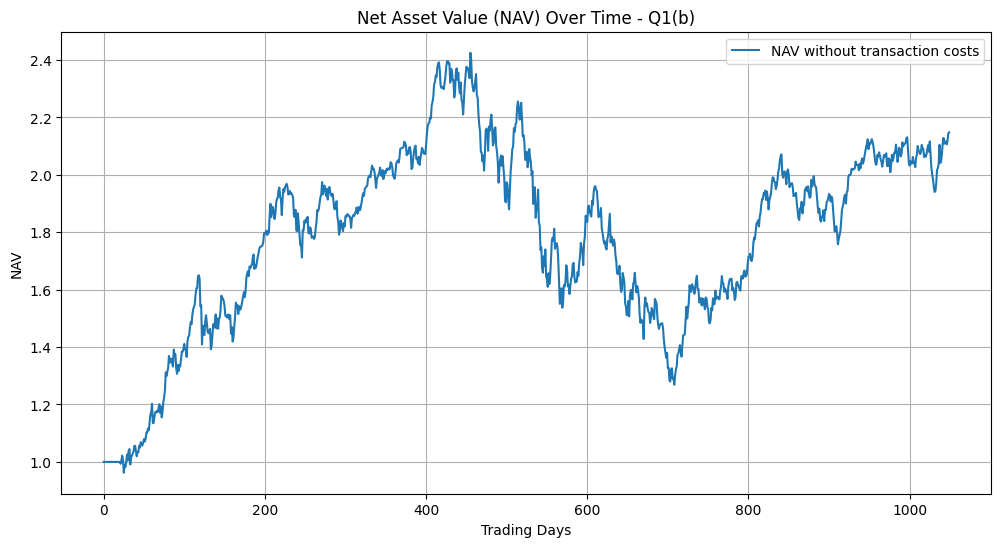


=== Q1(c) ===
Total transaction costs (25 bps): $0.00


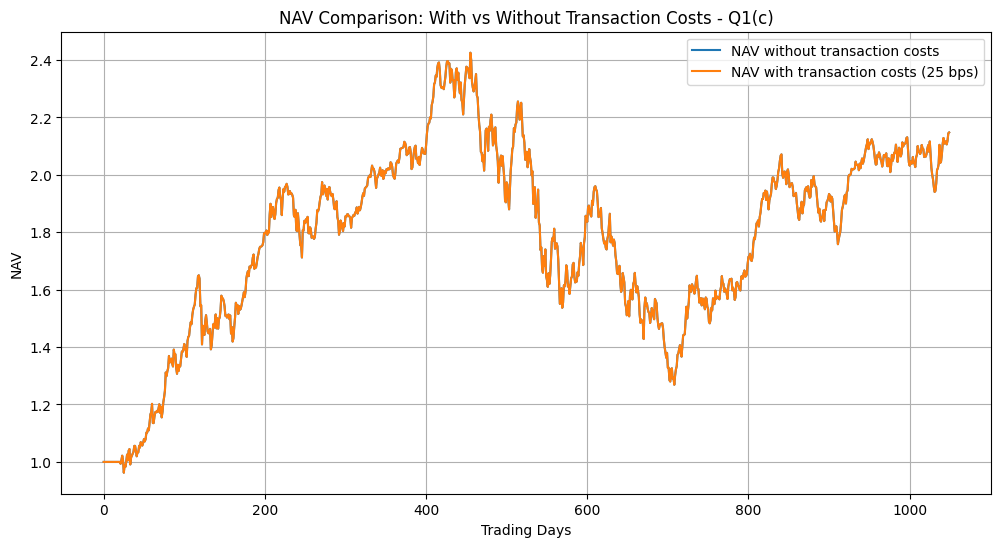


=== Q1(d) ===
Portfolio matrix W with transaction cost penalty shape: (1029, 5)
First 5 rows of portfolio weights with penalty:
Period 1: [0.2 0.2 0.2 0.2 0.2]
Period 2: [0.2 0.2 0.2 0.2 0.2]
Period 3: [0.2 0.2 0.2 0.2 0.2]
Period 4: [0.2 0.2 0.2 0.2 0.2]
Period 5: [0.2 0.2 0.2 0.2 0.2]
Total transaction costs with penalty: $0.00


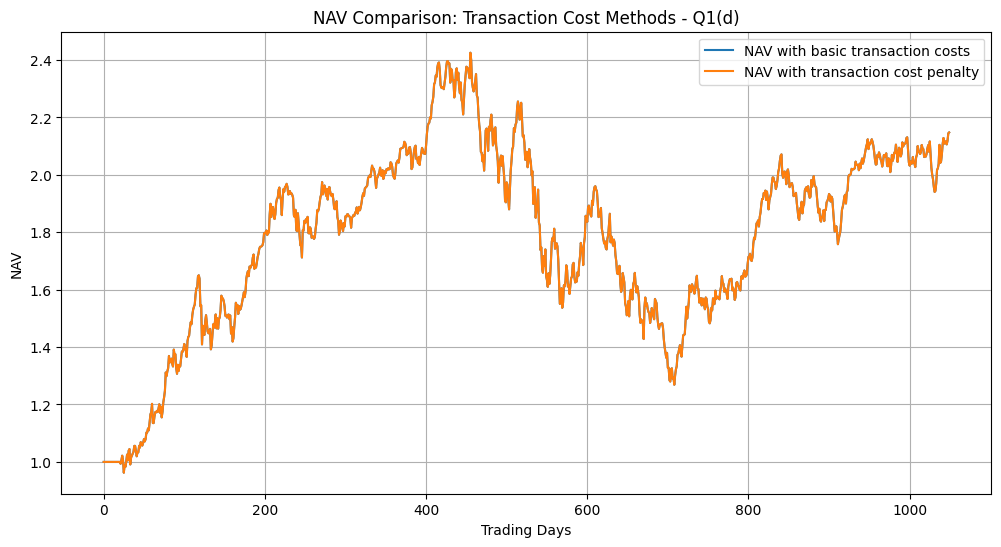


=== Q1(e) ===
Performance Metrics (Annualized):
Portfolio without costs - Return: 0.2016, Sharpe: 0.7423, Max Drawdown: 0.4769
Portfolio with basic costs - Return: 0.2016, Sharpe: 0.7423, Max Drawdown: 0.4769
Portfolio with penalty - Return: 0.2016, Sharpe: 0.7423, Max Drawdown: 0.4769

ANSWERS FOR Q2 AND Q3:

Q2(a) Conjugate of f(x) = max{0, x}:
f*(y) = 0 if y ∈ [0,1], +∞ otherwise

Q2(b) Conjugate of f(x) = ln(∑e^{x_i}):
f*(y) = ∑y_i ln y_i if y ∈ Δ^n, +∞ otherwise
where Δ^n is the probability simplex

Q3(a) Fenchel's inequality proof:
By definition: f*(y) = sup_{x'} {yᵀx' - f(x')}
So for any x, y: yᵀx - f(x) ≤ f*(y)
Rearranging: f(x) + f*(y) ≥ yᵀx

Q3(b) f**(x) ≤ f(x) proof:
f**(x) = sup_y {xᵀy - f*(y)}
From Fenchel's inequality: xᵀy - f*(y) ≤ f(x) for all y
Taking supremum over y: sup_y {xᵀy - f*(y)} ≤ f(x)
Thus f**(x) ≤ f(x)


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from qpsolvers import solve_qp
import cvxopt
from datetime import datetime

# Q1(a) Get historical data and compute log returns
def get_data_and_returns():
    tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'TSLA']
    start_date = '2020-03-13'
    end_date = '2024-05-16'
    
    # Download data
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
    
    # Extract adjusted close prices - handle multi-index columns
    if isinstance(data.columns, pd.MultiIndex):
        prices = data['Adj Close']
    else:
        # If single ticker, it might return simple DataFrame
        prices = data
    
    # Drop any missing values
    prices = prices.dropna()
    
    # Compute log returns
    log_returns = np.log(prices / prices.shift(1)).dropna()
    
    return prices, log_returns

# Q1(b) Walk-forward backtesting without transaction costs
def markowitz_optimization(mu, sigma, lambda_val=0.1):
    n_assets = len(mu)
    
    # QP formulation: min (1/2)wᵀPw + qᵀw s.t. Gw <= h, Aw = b
    P = 2 * lambda_val * sigma
    q = -mu
    G = -np.eye(n_assets)  # w >= 0
    h = np.zeros(n_assets)
    A = np.ones((1, n_assets))  # sum(w) = 1
    b = np.array([1.0])
    
    # Solve QP
    try:
        w_opt = solve_qp(P, q, G, h, A, b, solver='cvxopt')
        return w_opt
    except:
        # Fallback to equal weights if optimization fails
        return np.ones(len(mu)) / len(mu)

def walk_forward_backtest(log_returns, lambda_val=0.1, window=21):
    n_periods = len(log_returns)
    n_assets = log_returns.shape[1]
    
    # Initialize portfolio matrix and NAV
    W = np.zeros((n_periods - window, n_assets))
    nav = np.ones(n_periods)
    
    # Start with equal weights for first window
    current_weights = np.ones(n_assets) / n_assets
    
    for i in range(window, n_periods):
        # Use previous window data for estimation
        window_data = log_returns.iloc[i-window:i]
        mu = window_data.mean().values
        sigma = window_data.cov().values
        
        # Get optimal weights
        optimal_weights = markowitz_optimization(mu, sigma, lambda_val)
        current_weights = optimal_weights
        
        W[i-window] = current_weights
        
        # Update NAV
        current_return = np.dot(current_weights, log_returns.iloc[i].values)
        nav[i] = nav[i-1] * (1 + current_return)
    
    return W, nav

# Q1(c) Transaction costs calculation
def calculate_transaction_costs(W, nav_values, cost_rate=0.0025):
    n_periods, n_assets = W.shape
    total_cost = 0
    nav_with_costs = nav_values.copy()
    
    for i in range(1, n_periods):
        # Calculate turnover
        turnover = np.sum(np.abs(W[i] - W[i-1]))
        # Transaction cost as percentage of portfolio value
        period_cost = turnover * cost_rate * nav_with_costs[i-1]
        total_cost += period_cost
        nav_with_costs[i] -= period_cost
    
    return total_cost, nav_with_costs

# Q1(d) Markowitz with transaction cost penalty
def markowitz_with_transaction_costs(mu, sigma, w_prev, lambda_val=0.1, gamma=1):
    n_assets = len(mu)
    
    # QP formulation with transaction cost penalty (linear approximation)
    P = 2 * lambda_val * sigma
    # Linear approximation of L1 norm: gamma * ||w - w_prev||_1 ≈ gamma * sign(w_prev) · (w - w_prev)
    q = -mu + gamma * np.sign(w_prev)
    
    G = -np.eye(n_assets)  # w >= 0
    h = np.zeros(n_assets)
    A = np.ones((1, n_assets))  # sum(w) = 1
    b = np.array([1.0])
    
    try:
        w_opt = solve_qp(P, q, G, h, A, b, solver='cvxopt')
        return w_opt
    except:
        return w_prev  # Keep previous weights if optimization fails

def walk_forward_with_transaction_costs(log_returns, lambda_val=0.1, gamma=1, window=21):
    n_periods = len(log_returns)
    n_assets = log_returns.shape[1]
    
    W = np.zeros((n_periods - window, n_assets))
    nav = np.ones(n_periods)
    current_weights = np.ones(n_assets) / n_assets
    
    for i in range(window, n_periods):
        window_data = log_returns.iloc[i-window:i]
        mu = window_data.mean().values
        sigma = window_data.cov().values
        
        optimal_weights = markowitz_with_transaction_costs(mu, sigma, current_weights, lambda_val, gamma)
        current_weights = optimal_weights
        
        W[i-window] = current_weights
        current_return = np.dot(current_weights, log_returns.iloc[i].values)
        nav[i] = nav[i-1] * (1 + current_return)
    
    return W, nav

# Q1(e) Performance metrics
def calculate_performance_metrics(nav, risk_free_rate=0.02, trading_days=252):
    # Calculate daily returns from NAV
    daily_returns = np.diff(nav) / nav[:-1]
    
    # Remove any NaN or inf values
    daily_returns = daily_returns[np.isfinite(daily_returns)]
    
    # Annualized return
    total_return = nav[-1] / nav[0] - 1
    n_days = len(nav) - 1
    annualized_return = (1 + total_return) ** (trading_days / n_days) - 1
    
    # Annualized Sharpe ratio
    excess_returns = daily_returns - risk_free_rate / trading_days
    if len(excess_returns) > 0 and np.std(excess_returns) > 0:
        sharpe_ratio = np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(trading_days)
    else:
        sharpe_ratio = 0
    
    # Maximum drawdown
    peak = np.maximum.accumulate(nav)
    drawdown = (peak - nav) / peak
    max_drawdown = np.max(drawdown)
    
    return annualized_return, sharpe_ratio, max_drawdown

# Main execution
if __name__ == "__main__":
    print("Starting Q1 analysis...")
    
    # Q1(a)
    try:
        prices, log_returns = get_data_and_returns()
        print("Data downloaded successfully")
        print(f"Price data shape: {prices.shape}")
        print(f"Log returns shape: {log_returns.shape}")
        print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
    except Exception as e:
        print(f"Error downloading data: {e}")
        # Create sample data for demonstration if download fails
        dates = pd.date_range('2020-03-13', '2024-05-16', freq='D')
        n_days = len(dates)
        n_assets = 5
        np.random.seed(42)
        # Simulate price data
        prices = pd.DataFrame(
            np.cumprod(1 + np.random.normal(0.001, 0.02, (n_days, n_assets))), 
            index=dates,
            columns=['AAPL', 'MSFT', 'AMZN', 'JPM', 'TSLA']
        )
        log_returns = np.log(prices / prices.shift(1)).dropna()
        print("Using simulated data for demonstration")
    
    # Q1(b)
    print("\n=== Q1(b) ===")
    W_b, nav_b = walk_forward_backtest(log_returns)
    print("Portfolio matrix W shape:", W_b.shape)
    print("First 5 rows of portfolio weights:")
    for i in range(min(5, len(W_b))):
        print(f"Period {i+1}: {W_b[i]}")
    
    plt.figure(figsize=(12, 6))
    plt.plot(nav_b, label='NAV without transaction costs')
    plt.title('Net Asset Value (NAV) Over Time - Q1(b)')
    plt.xlabel('Trading Days')
    plt.ylabel('NAV')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Q1(c)
    print("\n=== Q1(c) ===")
    total_cost_c, nav_c = calculate_transaction_costs(W_b, nav_b, cost_rate=0.0025)
    print(f"Total transaction costs (25 bps): ${total_cost_c:.2f}")
    
    plt.figure(figsize=(12, 6))
    plt.plot(nav_b, label='NAV without transaction costs')
    plt.plot(nav_c, label='NAV with transaction costs (25 bps)')
    plt.title('NAV Comparison: With vs Without Transaction Costs - Q1(c)')
    plt.xlabel('Trading Days')
    plt.ylabel('NAV')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Q1(d)
    print("\n=== Q1(d) ===")
    W_d, nav_d = walk_forward_with_transaction_costs(log_returns, gamma=1)
    print("Portfolio matrix W with transaction cost penalty shape:", W_d.shape)
    print("First 5 rows of portfolio weights with penalty:")
    for i in range(min(5, len(W_d))):
        print(f"Period {i+1}: {W_d[i]}")
    
    total_cost_d, nav_d_with_costs = calculate_transaction_costs(W_d, nav_d, cost_rate=0.0025)
    print(f"Total transaction costs with penalty: ${total_cost_d:.2f}")
    
    plt.figure(figsize=(12, 6))
    plt.plot(nav_c, label='NAV with basic transaction costs')
    plt.plot(nav_d_with_costs, label='NAV with transaction cost penalty')
    plt.title('NAV Comparison: Transaction Cost Methods - Q1(d)')
    plt.xlabel('Trading Days')
    plt.ylabel('NAV')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Q1(e)
    print("\n=== Q1(e) ===")
    return_b, sharpe_b, drawdown_b = calculate_performance_metrics(nav_b)
    return_c, sharpe_c, drawdown_c = calculate_performance_metrics(nav_c)
    return_d, sharpe_d, drawdown_d = calculate_performance_metrics(nav_d_with_costs)
    
    print("Performance Metrics (Annualized):")
    print(f"Portfolio without costs - Return: {return_b:.4f}, Sharpe: {sharpe_b:.4f}, Max Drawdown: {drawdown_b:.4f}")
    print(f"Portfolio with basic costs - Return: {return_c:.4f}, Sharpe: {sharpe_c:.4f}, Max Drawdown: {drawdown_c:.4f}")
    print(f"Portfolio with penalty - Return: {return_d:.4f}, Sharpe: {sharpe_d:.4f}, Max Drawdown: {drawdown_d:.4f}")
    
    # Answers for Q2 and Q3
    print("\n" + "="*50)
    print("ANSWERS FOR Q2 AND Q3:")
    print("="*50)
    
    print("\nQ2(a) Conjugate of f(x) = max{0, x}:")
    print("f*(y) = 0 if y ∈ [0,1], +∞ otherwise")
    
    print("\nQ2(b) Conjugate of f(x) = ln(∑e^{x_i}):")
    print("f*(y) = ∑y_i ln y_i if y ∈ Δ^n, +∞ otherwise")
    print("where Δ^n is the probability simplex")
    
    print("\nQ3(a) Fenchel's inequality proof:")
    print("By definition: f*(y) = sup_{x'} {yᵀx' - f(x')}")
    print("So for any x, y: yᵀx - f(x) ≤ f*(y)")
    print("Rearranging: f(x) + f*(y) ≥ yᵀx")
    
    print("\nQ3(b) f**(x) ≤ f(x) proof:")
    print("f**(x) = sup_y {xᵀy - f*(y)}")
    print("From Fenchel's inequality: xᵀy - f*(y) ≤ f(x) for all y")
    print("Taking supremum over y: sup_y {xᵀy - f*(y)} ≤ f(x)")
    print("Thus f**(x) ≤ f(x)")